
# Part B — 10 Forecast Modeling & Walk-Forward Validation

## Goal

Test whether Toronto seasonal snowfall can be forecast **better than simple climatology** using only information available before winter.

This notebook compares:

1. **Historical climatology** — mean snowfall from all prior usable winters
2. **Rolling 10-season climatology** — mean snowfall from the most recent 10 prior usable winters
3. **Linear Regression**
4. **ElasticNet**
5. **CatBoost**

## Validation design

We use **expanding-window / walk-forward validation**.

Example:

```text
Train through 1970 → predict 1971
Train through 1971 → predict 1972
Train through 1972 → predict 1973
...
```

There is **no random train/test split**.

Primary metrics:

- **MAE** — average absolute snowfall error in cm
- **RMSE** — penalizes large forecast misses more strongly
- **Skill vs climatology** — improvement relative to the historical-mean baseline

## Important

This notebook evaluates **point forecasts** first.

Probabilistic forecasts, prediction intervals, below/near/above-normal probabilities, calibration, retraining, and agent automation come after we establish that the forecasting signal is useful.


In [1]:

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.linear_model import LinearRegression, ElasticNetCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)

# CatBoost is optional but recommended.
try:
    from catboost import CatBoostRegressor
    CATBOOST_AVAILABLE = True
except ImportError:
    CATBOOST_AVAILABLE = False
    print(
        "CatBoost is not installed in this environment.\n"
        "Install it with:  pip install catboost\n"
        "The rest of the notebook will still run."
    )

cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"

for directory in [PROCESSED_DIR, FIGURES_DIR, MODELS_DIR, REPORTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)


CatBoost is not installed in this environment.
Install it with:  pip install catboost
The rest of the notebook will still run.
Project root: /Users/toor/Desktop/Weather-Prediction/toronto-climate-analysis


## 1. Load Part B data

In [2]:

SEASONAL_PATH = PROCESSED_DIR / "pearson_seasonal_snowfall.csv"
FEATURES_FULL_PATH = PROCESSED_DIR / "forecast_features_full.csv"

if not SEASONAL_PATH.exists():
    raise FileNotFoundError(
        "pearson_seasonal_snowfall.csv is missing. "
        "Run notebook 08 first."
    )

if not FEATURES_FULL_PATH.exists():
    raise FileNotFoundError(
        "forecast_features_full.csv is missing. "
        "Run notebook 09 first."
    )

seasonal = pd.read_csv(SEASONAL_PATH)
feature_source = pd.read_csv(FEATURES_FULL_PATH)

print("Seasonal rows:", len(seasonal))
print("Feature-source rows:", len(feature_source))
display(seasonal.head())


Seasonal rows: 91
Feature-source rows: 84


,season_year,snowfall_cm,valid_days,missing_days,measurable_snow_days,expected_days,coverage_pct,usable_90pct,full_calendar_window,usable
0,1937,NaN,0,181,0,365,0.000000,False,False,False
1,1938,91.7,242,123,20,365,66.301370,False,True,False
2,1939,207.4,365,0,65,365,100.000000,True,True,True
3,1940,89.5,244,122,31,366,66.666667,False,True,False
4,1941,164.0,365,0,40,365,100.000000,True,True,True



## 2. Rebuild leakage-safe calendar lag features

Notebook 09 originally calculated some lag features after removing low-quality target seasons.

That can silently make `lag1` mean "previous usable winter" instead of the **previous calendar winter**.

Here we correct that.

### Rule

1. Keep the full chronological season sequence.
2. Replace snowfall with `NaN` when the target season is not trustworthy.
3. Shift by one calendar season.
4. Calculate rolling statistics over prior calendar windows only.
5. Only then choose rows that can be used as prediction targets.

This preserves the real timeline.


In [3]:
# Merge winter-quality information back onto the seasonal snowfall table
quality_cols = [
    "season_year",
    "winter_coverage_pct",
]

quality_lookup = (
    feature_source[quality_cols]
    .drop_duplicates("season_year")
)

data = (
    seasonal
    .merge(quality_lookup, on="season_year", how="left")
    .sort_values("season_year")
    .reset_index(drop=True)
)

# Strict target-quality rule
data["usable_strict"] = (
    data["usable"].fillna(False)
    & (data["winter_coverage_pct"] >= 98)
)

# Only trustworthy snowfall values are allowed to feed lag features
data["snowfall_clean_cm"] = data["snowfall_cm"].where(
    data["usable_strict"]
)

# Exact previous calendar winter
data["snow_lag1_cm"] = (
    data["snowfall_clean_cm"].shift(1)
)

# Rolling historical features
prior_snow = data["snowfall_clean_cm"].shift(1)

data["snow_roll5_mean_cm"] = (
    prior_snow
    .rolling(window=5, min_periods=3)
    .mean()
)

data["snow_roll10_mean_cm"] = (
    prior_snow
    .rolling(window=10, min_periods=5)
    .mean()
)

data["snow_roll10_std_cm"] = (
    prior_snow
    .rolling(window=10, min_periods=5)
    .std()
)

# Was the immediately previous calendar winter usable?
data["previous_season_usable"] = (
    data["usable_strict"]
    .shift(1)
    .fillna(False)
    .astype(bool)
)

# Do not use an unreliable previous winter as lag1
data.loc[
    data["previous_season_usable"].eq(False),
    "snow_lag1_cm"
] = np.nan

display(
    data[
        [
            "season_year",
            "snowfall_cm",
            "usable_strict",
            "snow_lag1_cm",
            "snow_roll5_mean_cm",
            "snow_roll10_mean_cm",
            "snow_roll10_std_cm",
        ]
    ].head(20)
)

,season_year,snowfall_cm,usable_strict,snow_lag1_cm,snow_roll5_mean_cm,snow_roll10_mean_cm,snow_roll10_std_cm
0,1937,NaN,False,NaN,NaN,NaN,NaN
1,1938,91.7,False,NaN,NaN,NaN,NaN
2,1939,207.4,True,NaN,NaN,NaN,NaN
3,1940,89.5,False,207.4,NaN,NaN,NaN
4,1941,164.0,True,NaN,NaN,NaN,NaN
5,1942,96.9,True,164.0,NaN,NaN,NaN
6,1943,182.4,True,96.9,156.100,NaN,NaN
7,1944,123.7,True,182.4,162.675,NaN,NaN
8,1945,162.3,True,123.7,141.750,154.880000,44.532988
9,1946,89.5,True,162.3,145.860,156.116667,39.946535


## 3. Merge ENSO and pre-winter climate predictors

In [4]:

predictor_cols = [
    "season_year",
    "oni_jas",
    "oni_phase_threshold",
    "sep_oct_mean_temp_c",
    "sep_oct_total_precip_mm",
    "sep_oct_temp_coverage_pct",
    "sep_oct_precip_coverage_pct",
    "autumn_features_usable",
    "year_index",
]

predictors = (
    feature_source[predictor_cols]
    .drop_duplicates("season_year")
)

model_table = (
    data.merge(
        predictors,
        on="season_year",
        how="left"
    )
    .sort_values("season_year")
    .reset_index(drop=True)
)

FEATURES = [
    "oni_jas",
    "sep_oct_mean_temp_c",
    "sep_oct_total_precip_mm",
    "snow_lag1_cm",
    "snow_roll5_mean_cm",
    "snow_roll10_mean_cm",
    "snow_roll10_std_cm",
    "year_index",
]

# A target season must itself be trustworthy.
# Local autumn predictors must also pass their quality check.
model_data = model_table[
    model_table["usable_strict"]
    & model_table["autumn_features_usable"].fillna(False)
].copy()

# Require all selected model features.
model_data = model_data.dropna(
    subset=["snowfall_cm"] + FEATURES
).reset_index(drop=True)

print("Model-ready rows after calendar-lag correction:", len(model_data))
print(
    "Season range:",
    model_data["season_year"].min(),
    "→",
    model_data["season_year"].max()
)

display(
    model_data[
        ["season_year", "snowfall_cm"] + FEATURES
    ].head(10)
)


Model-ready rows after calendar-lag correction: 70
Season range: 1951 → 2026


,season_year,snowfall_cm,oni_jas,sep_oct_mean_temp_c,sep_oct_total_precip_mm,snow_lag1_cm,snow_roll5_mean_cm,snow_roll10_mean_cm,snow_roll10_std_cm,year_index
0,1951,111.8,-0.57,12.640984,100.0,196.4,136.22,141.04,35.388077,12.0
1,1952,184.8,0.90,12.634426,102.3,111.8,140.68,135.82,35.474836,13.0
2,1953,53.9,-0.20,11.896721,77.4,184.8,148.28,144.61,35.649231,14.0
3,1954,124.7,0.68,13.195082,92.5,53.9,134.68,131.76,42.929922,15.0
4,1955,109.3,-0.83,13.193443,294.6,124.7,134.32,131.86,42.910222,16.0
5,1956,160.0,-0.92,13.373770,107.9,109.3,116.90,126.56,41.996090,17.0
6,1957,117.3,-0.52,11.755738,63.0,160.0,126.54,133.61,40.988900,18.0
7,1958,96.1,1.03,12.334426,141.5,117.3,113.04,130.66,40.995696,19.0
8,1959,146.5,0.32,13.072131,110.0,96.1,121.48,128.08,42.396169,20.0
9,1960,141.5,-0.23,14.129508,148.8,146.5,125.84,130.08,42.783325,21.0



### Sanity checks

The following assertions ensure:

- seasons are chronological,
- there are no duplicate targets,
- no selected modeling feature is missing.


In [5]:

assert model_data["season_year"].is_monotonic_increasing
assert model_data["season_year"].is_unique
assert model_data[["snowfall_cm"] + FEATURES].notna().all().all()

print("Sanity checks passed.")


Sanity checks passed.


## 4. Define walk-forward evaluation


We will use the first **20 model-ready winters** as the minimum training history.

After that, every following winter is predicted one at a time using only earlier observations.

Using one common set of test winters makes the model comparison fair.


In [6]:

MIN_TRAIN_SIZE = 20

if len(model_data) <= MIN_TRAIN_SIZE:
    raise ValueError(
        f"Need more than {MIN_TRAIN_SIZE} model-ready rows. "
        f"Found only {len(model_data)}."
    )

FIRST_TEST_SEASON = int(model_data.iloc[MIN_TRAIN_SIZE]["season_year"])
LAST_TEST_SEASON = int(model_data.iloc[-1]["season_year"])

print("Minimum training observations:", MIN_TRAIN_SIZE)
print("First walk-forward test season:", FIRST_TEST_SEASON)
print("Last walk-forward test season:", LAST_TEST_SEASON)
print("Number of out-of-sample forecasts:", len(model_data) - MIN_TRAIN_SIZE)


Minimum training observations: 20
First walk-forward test season: 1971
Last walk-forward test season: 2026
Number of out-of-sample forecasts: 50


## 5. Define models

In [7]:

def make_linear_model():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ])


def make_elasticnet_model(n_train):
    # Nested time-aware CV inside each expanding training fold.
    n_splits = min(5, max(2, n_train // 6))

    return Pipeline([
        ("scaler", StandardScaler()),
        (
            "model",
            ElasticNetCV(
                l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
                alphas=np.logspace(-3, 2, 60),
                cv=TimeSeriesSplit(n_splits=n_splits),
                max_iter=20000,
            )
        )
    ])


def make_catboost_model():
    if not CATBOOST_AVAILABLE:
        return None

    return CatBoostRegressor(
        iterations=400,
        depth=4,
        learning_rate=0.03,
        loss_function="RMSE",
        l2_leaf_reg=5,
        random_seed=42,
        verbose=False,
        allow_writing_files=False,
    )



### Why CatBoost is deliberately modest here

We only have a small number of winters.

A very deep or aggressively tuned boosting model would be easy to overfit.

For the first comparison we use a conservative fixed configuration. Hyperparameter tuning belongs later, after we know whether CatBoost has real walk-forward skill.


## 6. Walk-forward forecasting

In [8]:

records = []

X_all = model_data[FEATURES]
y_all = model_data["snowfall_cm"]

for test_idx in range(MIN_TRAIN_SIZE, len(model_data)):
    train = model_data.iloc[:test_idx].copy()
    test = model_data.iloc[[test_idx]].copy()

    X_train = train[FEATURES]
    y_train = train["snowfall_cm"]
    X_test = test[FEATURES]

    actual = float(test["snowfall_cm"].iloc[0])
    season_year = int(test["season_year"].iloc[0])

    # ---------------------------------------------------------
    # Baseline 1: historical climatology
    # ---------------------------------------------------------
    pred_climatology = float(y_train.mean())

    records.append({
        "season_year": season_year,
        "model": "Historical Climatology",
        "actual_cm": actual,
        "predicted_cm": pred_climatology,
        "train_n": len(train),
    })

    # ---------------------------------------------------------
    # Baseline 2: last 10 prior training targets
    # ---------------------------------------------------------
    pred_roll10 = float(y_train.tail(10).mean())

    records.append({
        "season_year": season_year,
        "model": "Rolling 10-Season Mean",
        "actual_cm": actual,
        "predicted_cm": pred_roll10,
        "train_n": len(train),
    })

    # ---------------------------------------------------------
    # Linear Regression
    # ---------------------------------------------------------
    linear = make_linear_model()
    linear.fit(X_train, y_train)

    pred_linear = float(linear.predict(X_test)[0])

    records.append({
        "season_year": season_year,
        "model": "Linear Regression",
        "actual_cm": actual,
        "predicted_cm": pred_linear,
        "train_n": len(train),
    })

    # ---------------------------------------------------------
    # ElasticNet with time-aware nested CV
    # ---------------------------------------------------------
    elastic = make_elasticnet_model(len(train))
    elastic.fit(X_train, y_train)

    pred_elastic = float(elastic.predict(X_test)[0])

    records.append({
        "season_year": season_year,
        "model": "ElasticNet",
        "actual_cm": actual,
        "predicted_cm": pred_elastic,
        "train_n": len(train),
    })

    # ---------------------------------------------------------
    # CatBoost
    # ---------------------------------------------------------
    if CATBOOST_AVAILABLE:
        cat = make_catboost_model()
        cat.fit(X_train, y_train)

        pred_cat = float(cat.predict(X_test)[0])

        records.append({
            "season_year": season_year,
            "model": "CatBoost",
            "actual_cm": actual,
            "predicted_cm": pred_cat,
            "train_n": len(train),
        })

predictions = pd.DataFrame(records)
predictions["error_cm"] = (
    predictions["predicted_cm"] - predictions["actual_cm"]
)
predictions["abs_error_cm"] = predictions["error_cm"].abs()
predictions["squared_error"] = predictions["error_cm"] ** 2

print("Prediction rows:", len(predictions))
display(predictions.head(12))


Prediction rows: 200


,season_year,model,actual_cm,predicted_cm,train_n,error_cm,abs_error_cm,squared_error
0,1971,Historical Climatology,171.7,130.045000,20,-41.655000,41.655000,1735.139025
1,1971,Rolling 10-Season Mean,171.7,135.500000,20,-36.200000,36.200000,1310.440000
2,1971,Linear Regression,171.7,114.644873,20,-57.055127,57.055127,3255.287533
3,1971,ElasticNet,171.7,129.662206,20,-42.037794,42.037794,1767.176155
4,1972,Historical Climatology,188.9,132.028571,21,-56.871429,56.871429,3234.359388
5,1972,Rolling 10-Season Mean,188.9,140.320000,21,-48.580000,48.580000,2360.016400
6,1972,Linear Regression,188.9,115.890750,21,-73.009250,73.009250,5330.350655
7,1972,ElasticNet,188.9,132.028571,21,-56.871429,56.871429,3234.359388
8,1973,Historical Climatology,110.0,134.613636,22,24.613636,24.613636,605.831095
9,1973,Rolling 10-Season Mean,110.0,145.720000,22,35.720000,35.720000,1275.918400


## 7. Compare out-of-sample performance

In [9]:

def rmse(actual, predicted):
    return np.sqrt(mean_squared_error(actual, predicted))


comparison = (
    predictions.groupby("model")
    .apply(
        lambda g: pd.Series({
            "n_forecasts": len(g),
            "MAE_cm": mean_absolute_error(
                g["actual_cm"],
                g["predicted_cm"]
            ),
            "RMSE_cm": rmse(
                g["actual_cm"],
                g["predicted_cm"]
            ),
            "Bias_cm": g["error_cm"].mean(),
        }),
        include_groups=False
    )
    .reset_index()
)

climatology_mae = float(
    comparison.loc[
        comparison["model"] == "Historical Climatology",
        "MAE_cm"
    ].iloc[0]
)

comparison["MAE_skill_vs_climatology_pct"] = (
    1 - comparison["MAE_cm"] / climatology_mae
) * 100

comparison = comparison.sort_values(
    ["MAE_cm", "RMSE_cm"]
).reset_index(drop=True)

display(
    comparison.style.format({
        "n_forecasts": "{:.0f}",
        "MAE_cm": "{:.2f}",
        "RMSE_cm": "{:.2f}",
        "Bias_cm": "{:+.2f}",
        "MAE_skill_vs_climatology_pct": "{:+.1f}%"
    })
)


,model,n_forecasts,MAE_cm,RMSE_cm,Bias_cm,MAE_skill_vs_climatology_pct
0,Historical Climatology,50,31.56,37.87,+9.92,+0.0%
1,ElasticNet,50,31.64,37.97,+8.84,-0.2%
2,Rolling 10-Season Mean,50,31.68,37.72,+0.64,-0.4%
3,Linear Regression,50,34.24,42.10,+0.92,-8.5%



### How to read skill

- `+10%` means the model's MAE is 10% lower than historical climatology.
- `0%` means no improvement.
- A negative value means the model is **worse** than simply predicting the historical mean.

A more complex model is not automatically better.


## 8. Identify the best walk-forward model

In [10]:

best_row = comparison.iloc[0]

BEST_MODEL_NAME = best_row["model"]
BEST_MAE = float(best_row["MAE_cm"])
BEST_RMSE = float(best_row["RMSE_cm"])

print("Best by walk-forward MAE:", BEST_MODEL_NAME)
print(f"MAE: {BEST_MAE:.2f} cm")
print(f"RMSE: {BEST_RMSE:.2f} cm")
print(
    f"Skill vs climatology: "
    f"{float(best_row['MAE_skill_vs_climatology_pct']):+.1f}%"
)


Best by walk-forward MAE: Historical Climatology
MAE: 31.56 cm
RMSE: 37.87 cm
Skill vs climatology: +0.0%


## 9. Plot actual vs predicted snowfall

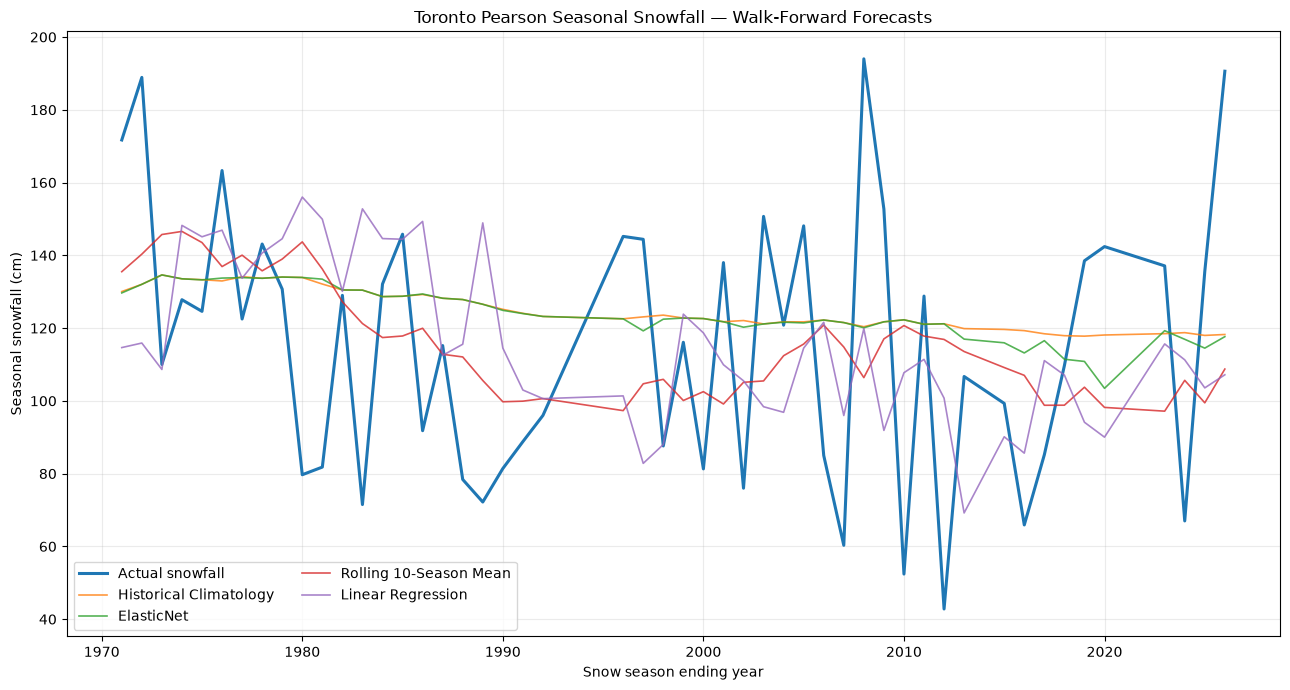

In [11]:

plot_models = comparison["model"].tolist()

fig, ax = plt.subplots(figsize=(13, 7))

actual_series = (
    predictions[
        predictions["model"] == "Historical Climatology"
    ][["season_year", "actual_cm"]]
    .drop_duplicates("season_year")
)

ax.plot(
    actual_series["season_year"],
    actual_series["actual_cm"],
    linewidth=2.2,
    label="Actual snowfall"
)

for model_name in plot_models:
    g = predictions[
        predictions["model"] == model_name
    ]

    ax.plot(
        g["season_year"],
        g["predicted_cm"],
        linewidth=1.2,
        alpha=0.8,
        label=model_name
    )

ax.set_title("Toronto Pearson Seasonal Snowfall — Walk-Forward Forecasts")
ax.set_xlabel("Snow season ending year")
ax.set_ylabel("Seasonal snowfall (cm)")
ax.grid(alpha=0.25)
ax.legend(ncol=2)

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "part_b_walk_forward_predictions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 10. Plot model MAE

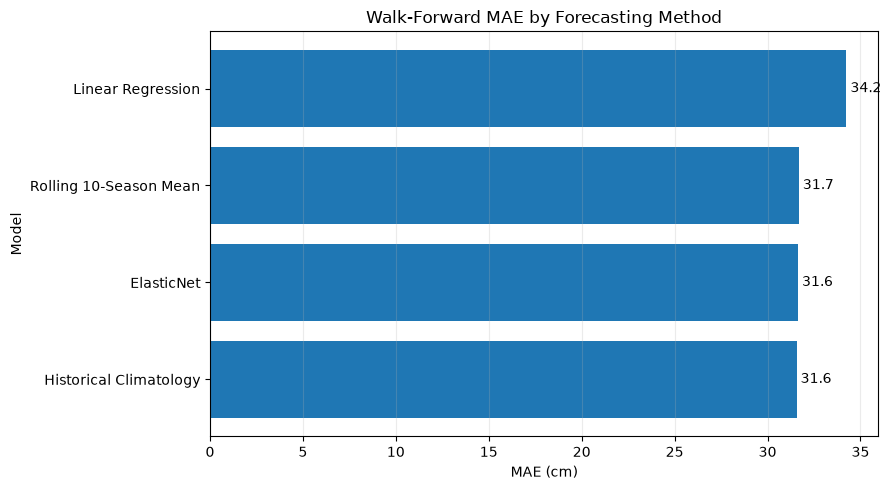

In [12]:

fig, ax = plt.subplots(figsize=(9, 5))

plot_comp = comparison.sort_values(
    "MAE_cm",
    ascending=True
)

ax.barh(
    plot_comp["model"],
    plot_comp["MAE_cm"]
)

ax.set_title("Walk-Forward MAE by Forecasting Method")
ax.set_xlabel("MAE (cm)")
ax.set_ylabel("Model")
ax.grid(axis="x", alpha=0.25)

for i, value in enumerate(plot_comp["MAE_cm"]):
    ax.text(
        value,
        i,
        f" {value:.1f}",
        va="center"
    )

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "part_b_model_mae.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 11. Error diagnostics for the best model

In [13]:

best_predictions = predictions[
    predictions["model"] == BEST_MODEL_NAME
].copy()

best_predictions["absolute_error_cm"] = (
    best_predictions["predicted_cm"]
    - best_predictions["actual_cm"]
).abs()

print("Largest misses:")
display(
    best_predictions.nlargest(
        10,
        "absolute_error_cm"
    )[
        [
            "season_year",
            "actual_cm",
            "predicted_cm",
            "error_cm",
            "absolute_error_cm"
        ]
    ]
)


Largest misses:


,season_year,actual_cm,predicted_cm,error_cm,absolute_error_cm
152,2012,42.8,121.182759,78.382759,78.382759
136,2008,194.0,120.383333,-73.616667,73.616667
196,2026,190.6,118.243478,-72.356522,72.356522
144,2010,52.4,122.275000,69.875000,69.875000
132,2007,60.3,121.516981,61.216981,61.216981
48,1983,71.5,130.437500,58.937500,58.937500
4,1972,188.9,132.028571,-56.871429,56.871429
72,1989,72.2,126.547368,54.347368,54.347368
36,1980,79.7,133.913793,54.213793,54.213793
164,2016,65.9,119.301639,53.401639,53.401639


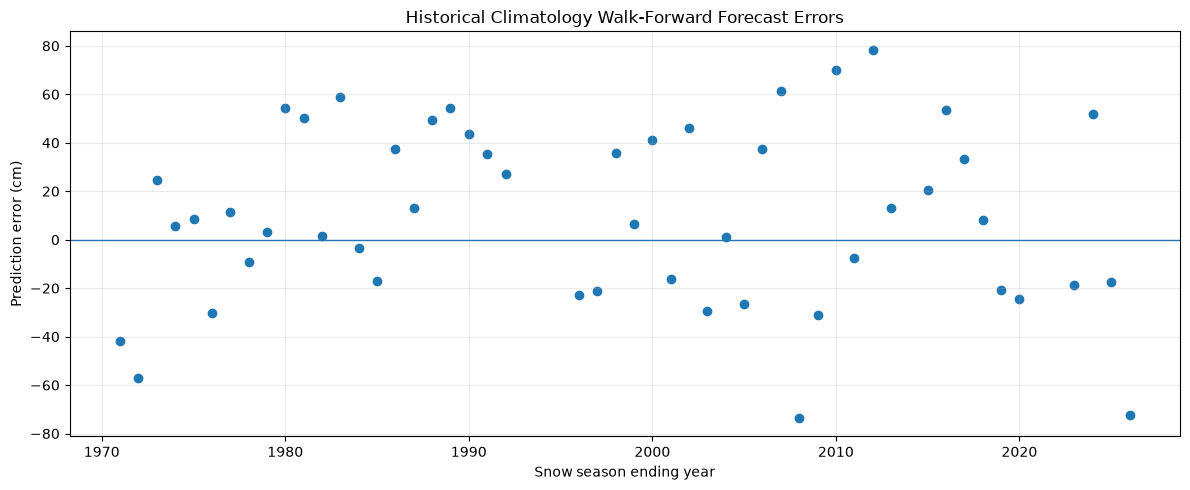

In [14]:

fig, ax = plt.subplots(figsize=(12, 5))

ax.axhline(0, linewidth=1)
ax.scatter(
    best_predictions["season_year"],
    best_predictions["error_cm"]
)

ax.set_title(f"{BEST_MODEL_NAME} Walk-Forward Forecast Errors")
ax.set_xlabel("Snow season ending year")
ax.set_ylabel("Prediction error (cm)")
ax.grid(alpha=0.25)

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "part_b_best_model_errors.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 12. Recent-period performance


A model can look acceptable over the full historical backtest but degrade in the modern climate.

We therefore also inspect the **most recent 15 out-of-sample winters**.

This is diagnostic only; the main model selection remains the full walk-forward comparison.


In [15]:

recent_years = sorted(
    predictions["season_year"].unique()
)[-15:]

recent_predictions = predictions[
    predictions["season_year"].isin(recent_years)
]

recent_comparison = (
    recent_predictions.groupby("model")
    .apply(
        lambda g: pd.Series({
            "n_forecasts": len(g),
            "MAE_cm": mean_absolute_error(
                g["actual_cm"],
                g["predicted_cm"]
            ),
            "RMSE_cm": rmse(
                g["actual_cm"],
                g["predicted_cm"]
            ),
            "Bias_cm": g["error_cm"].mean(),
        }),
        include_groups=False
    )
    .reset_index()
    .sort_values("MAE_cm")
)

display(
    recent_comparison.style.format({
        "n_forecasts": "{:.0f}",
        "MAE_cm": "{:.2f}",
        "RMSE_cm": "{:.2f}",
        "Bias_cm": "{:+.2f}",
    })
)


,model,n_forecasts,MAE_cm,RMSE_cm,Bias_cm
1,Historical Climatology,15,34.71,41.83,+9.07
0,ElasticNet,15,34.85,42.04,+5.88
3,Rolling 10-Season Mean,15,36.46,43.16,-2.80
2,Linear Regression,15,37.62,43.28,-10.53


## 13. Does ENSO add signal? Ablation test


A useful forecasting project should test whether an important feature actually contributes.

Here we compare **ElasticNet with ONI** against the same model **without ONI**, using the identical walk-forward test seasons.

This does not establish causality. It only checks whether ONI improves forecast accuracy in this modeling setup.


In [16]:

FEATURES_WITHOUT_ONI = [
    c for c in FEATURES
    if c != "oni_jas"
]

ablation_records = []

for test_idx in range(MIN_TRAIN_SIZE, len(model_data)):
    train = model_data.iloc[:test_idx]
    test = model_data.iloc[[test_idx]]

    actual = float(test["snowfall_cm"].iloc[0])
    season_year = int(test["season_year"].iloc[0])

    # With ONI
    model_with = make_elasticnet_model(len(train))
    model_with.fit(
        train[FEATURES],
        train["snowfall_cm"]
    )
    pred_with = float(
        model_with.predict(test[FEATURES])[0]
    )

    # Without ONI
    model_without = make_elasticnet_model(len(train))
    model_without.fit(
        train[FEATURES_WITHOUT_ONI],
        train["snowfall_cm"]
    )
    pred_without = float(
        model_without.predict(
            test[FEATURES_WITHOUT_ONI]
        )[0]
    )

    ablation_records.extend([
        {
            "season_year": season_year,
            "version": "ElasticNet + ONI",
            "actual_cm": actual,
            "predicted_cm": pred_with,
        },
        {
            "season_year": season_year,
            "version": "ElasticNet without ONI",
            "actual_cm": actual,
            "predicted_cm": pred_without,
        },
    ])

ablation = pd.DataFrame(ablation_records)

ablation_comparison = (
    ablation.groupby("version")
    .apply(
        lambda g: pd.Series({
            "MAE_cm": mean_absolute_error(
                g["actual_cm"],
                g["predicted_cm"]
            ),
            "RMSE_cm": rmse(
                g["actual_cm"],
                g["predicted_cm"]
            ),
        }),
        include_groups=False
    )
    .reset_index()
    .sort_values("MAE_cm")
)

display(
    ablation_comparison.style.format({
        "MAE_cm": "{:.2f}",
        "RMSE_cm": "{:.2f}",
    })
)


,version,MAE_cm,RMSE_cm
0,ElasticNet + ONI,31.64,37.97
1,ElasticNet without ONI,31.64,38.02



### Interpretation

If `ElasticNet + ONI` performs better, ONI is adding predictive information in this setup.

If it performs the same or worse, we keep that result. We should **not force ENSO into the production model simply because it is meteorologically interesting**.


## 14. Fit the final candidate on all available model-ready history

In [17]:

X = model_data[FEATURES]
y = model_data["snowfall_cm"]

final_model = None
final_model_metadata = {
    "selected_by": "lowest walk-forward MAE",
    "best_model_name": BEST_MODEL_NAME,
    "walk_forward_mae_cm": BEST_MAE,
    "walk_forward_rmse_cm": BEST_RMSE,
    "training_start_season": int(model_data["season_year"].min()),
    "training_end_season": int(model_data["season_year"].max()),
    "n_training_rows": int(len(model_data)),
    "features": FEATURES,
}

if BEST_MODEL_NAME == "Linear Regression":
    final_model = make_linear_model()
    final_model.fit(X, y)

elif BEST_MODEL_NAME == "ElasticNet":
    final_model = make_elasticnet_model(len(model_data))
    final_model.fit(X, y)

elif BEST_MODEL_NAME == "CatBoost":
    if not CATBOOST_AVAILABLE:
        raise RuntimeError(
            "CatBoost was selected but is not installed."
        )
    final_model = make_catboost_model()
    final_model.fit(X, y)

elif BEST_MODEL_NAME == "Historical Climatology":
    final_model_metadata["climatology_mean_cm"] = float(y.mean())

elif BEST_MODEL_NAME == "Rolling 10-Season Mean":
    final_model_metadata["rolling10_mean_cm"] = float(y.tail(10).mean())

else:
    raise ValueError(f"Unknown model: {BEST_MODEL_NAME}")

print("Final candidate:", BEST_MODEL_NAME)


Final candidate: Historical Climatology


## 15. Save modeling outputs

In [18]:

PREDICTIONS_PATH = PROCESSED_DIR / "walk_forward_predictions.csv"
COMPARISON_PATH = PROCESSED_DIR / "forecast_model_comparison.csv"
MODEL_DATA_PATH = PROCESSED_DIR / "forecast_modeling_dataset.csv"
METADATA_PATH = MODELS_DIR / "snowfall_model_metadata.json"
MODEL_PATH = MODELS_DIR / "snowfall_forecast_model.joblib"

predictions.to_csv(PREDICTIONS_PATH, index=False)
comparison.to_csv(COMPARISON_PATH, index=False)
model_data.to_csv(MODEL_DATA_PATH, index=False)

with open(METADATA_PATH, "w") as f:
    json.dump(final_model_metadata, f, indent=2)

if final_model is not None:
    joblib.dump(final_model, MODEL_PATH)
    print("Saved fitted model:", MODEL_PATH)
else:
    print(
        "Best method is a statistical baseline, so no sklearn/CatBoost "
        "model object was required."
    )

print("Saved predictions:", PREDICTIONS_PATH)
print("Saved comparison:", COMPARISON_PATH)
print("Saved modeling dataset:", MODEL_DATA_PATH)
print("Saved metadata:", METADATA_PATH)


Best method is a statistical baseline, so no sklearn/CatBoost model object was required.
Saved predictions: /Users/toor/Desktop/Weather-Prediction/toronto-climate-analysis/data/processed/walk_forward_predictions.csv
Saved comparison: /Users/toor/Desktop/Weather-Prediction/toronto-climate-analysis/data/processed/forecast_model_comparison.csv
Saved modeling dataset: /Users/toor/Desktop/Weather-Prediction/toronto-climate-analysis/data/processed/forecast_modeling_dataset.csv
Saved metadata: /Users/toor/Desktop/Weather-Prediction/toronto-climate-analysis/models/snowfall_model_metadata.json


## 16. Generate a compact modeling report

In [19]:

report_lines = [
    "# Toronto Snowfall Forecasting — Walk-Forward Model Report",
    "",
    f"- Model-ready seasons: {len(model_data)}",
    f"- Training/evaluation range: {int(model_data['season_year'].min())}–{int(model_data['season_year'].max())}",
    f"- First out-of-sample forecast: {FIRST_TEST_SEASON}",
    f"- Number of out-of-sample winters: {len(model_data) - MIN_TRAIN_SIZE}",
    "",
    "## Model comparison",
    "",
]

for _, row in comparison.iterrows():
    report_lines.append(
        f"- {row['model']}: "
        f"MAE={row['MAE_cm']:.2f} cm, "
        f"RMSE={row['RMSE_cm']:.2f} cm, "
        f"bias={row['Bias_cm']:+.2f} cm, "
        f"skill vs climatology={row['MAE_skill_vs_climatology_pct']:+.1f}%"
    )

report_lines.extend([
    "",
    "## Selected candidate",
    "",
    f"**{BEST_MODEL_NAME}**",
    "",
    f"- Walk-forward MAE: {BEST_MAE:.2f} cm",
    f"- Walk-forward RMSE: {BEST_RMSE:.2f} cm",
    "",
    "The selected method is based on historical walk-forward performance. "
    "It is not yet a probabilistic forecast and has not yet entered the "
    "retraining/champion-challenger workflow.",
])

REPORT_PATH = REPORTS_DIR / "part_b_model_report.md"
REPORT_PATH.write_text("\n".join(report_lines))

print(REPORT_PATH.read_text())


# Toronto Snowfall Forecasting — Walk-Forward Model Report

- Model-ready seasons: 70
- Training/evaluation range: 1951–2026
- First out-of-sample forecast: 1971
- Number of out-of-sample winters: 50

## Model comparison

- Historical Climatology: MAE=31.56 cm, RMSE=37.87 cm, bias=+9.92 cm, skill vs climatology=+0.0%
- ElasticNet: MAE=31.64 cm, RMSE=37.97 cm, bias=+8.84 cm, skill vs climatology=-0.2%
- Rolling 10-Season Mean: MAE=31.68 cm, RMSE=37.72 cm, bias=+0.64 cm, skill vs climatology=-0.4%
- Linear Regression: MAE=34.24 cm, RMSE=42.10 cm, bias=+0.92 cm, skill vs climatology=-8.5%

## Selected candidate

**Historical Climatology**

- Walk-forward MAE: 31.56 cm
- Walk-forward RMSE: 37.87 cm

The selected method is based on historical walk-forward performance. It is not yet a probabilistic forecast and has not yet entered the retraining/champion-challenger workflow.



# Decision gate before probabilistic forecasting

After running this notebook, inspect:

1. **Which method has the lowest walk-forward MAE?**
2. **Does any ML model beat historical climatology?**
3. **How much skill does it gain?**
4. **Does performance remain reasonable in the recent 15 winters?**
5. **Does adding ONI improve ElasticNet?**
6. **Which winters produce the largest errors?**

## If ML beats the baselines

Proceed to:

### `11_probabilistic_snowfall_forecast.ipynb`

We will add:

- residual / quantile uncertainty,
- prediction intervals,
- below-normal probability,
- near-normal probability,
- above-normal probability,
- interval coverage,
- Brier score / calibration where appropriate.

## If climatology beats ML

That is still an important result.

We do **not** force a complex model into production. Instead, we revise the predictors, forecasting horizon, or target definition before moving forward.
